In [1]:
!pip install pyspark hdbscan -q

In [2]:
import re
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import ArrayType, StringType, IntegerType
from pyspark.sql.functions import udf

from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.clustering import KMeans as SparkKMeans
from pyspark.ml.evaluation import ClusteringEvaluator

from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import hdbscan

In [5]:
spark = (
    SparkSession.builder
    .appName("CERT-Insider-Threat-Clustering")
    .config("spark.driver.memory", "8g")
    .config("spark.sql.shuffle.partitions", "200")
    .getOrCreate()
)

spark

In [7]:
sdf = spark.read.csv("data/email_filtered.csv", header=True, inferSchema=True)
print("Raw rows:", sdf.count())
sdf.printSchema()

Raw rows: 2000
root
 |-- id: string (nullable = true)
 |-- date: string (nullable = true)
 |-- user: string (nullable = true)
 |-- pc: string (nullable = true)
 |-- to: string (nullable = true)
 |-- cc: string (nullable = true)
 |-- bcc: string (nullable = true)
 |-- from: string (nullable = true)
 |-- size: integer (nullable = true)
 |-- attachments: integer (nullable = true)
 |-- content: string (nullable = true)



In [9]:
sdf = sdf.withColumn(
    "date_ts",
    F.to_timestamp("date", "MM/dd/yyyy HH:mm:ss")
).dropna(subset=["date_ts", "user"])

for c in ["to", "cc", "bcc", "from", "content"]:
    if c in sdf.columns:
        sdf = sdf.fillna({c: ""})

for c in ["size", "attachments"]:
    if c in sdf.columns:
        sdf = sdf.fillna({c: 0})

sdf = (
    sdf.withColumn("day", F.to_date("date_ts"))
       .withColumn("hour", F.hour("date_ts"))
       .withColumn("weekday", F.dayofweek("date_ts"))
       .withColumn("off_hours", F.when((F.col("hour") < 8) | (F.col("hour") > 18), 1).otherwise(0))
       .withColumn("weekend", F.when((F.col("weekday").isin([1, 7])), 1).otherwise(0))
)

In [13]:
from pyspark.sql import functions as F

def extract_mailto(col_name):
    # Extract email after mailto: and before any closing ')' or end of string
    return F.lower(
        F.regexp_extract(F.col(col_name), r"mailto:([^)]+)", 1)
    )

sdf = (
    sdf.withColumn("to_email", extract_mailto("to"))
       .withColumn("cc_email", extract_mailto("cc"))
       .withColumn("bcc_email", extract_mailto("bcc"))
       .withColumn(
           "recipient_count",
           (F.when(F.length(F.col("to_email")) > 0, 1).otherwise(0) +
            F.when(F.length(F.col("cc_email")) > 0, 1).otherwise(0) +
            F.when(F.length(F.col("bcc_email")) > 0, 1).otherwise(0))
       )
       .withColumn(
           "external_recipient_count",
           (F.when((F.length(F.col("to_email")) > 0) & (~F.col("to_email").endswith("@dtaa.com")), 1).otherwise(0) +
            F.when((F.length(F.col("cc_email")) > 0) & (~F.col("cc_email").endswith("@dtaa.com")), 1).otherwise(0) +
            F.when((F.length(F.col("bcc_email")) > 0) & (~F.col("bcc_email").endswith("@dtaa.com")), 1).otherwise(0))
       )
)

sdf.select(
    "to", "to_email",
    "cc", "cc_email",
    "bcc", "bcc_email",
    "recipient_count", "external_recipient_count"
).show(5, truncate=False)


+-------------------------------+--------+----------------------------+--------+-----------------------------+---------+---------------+------------------------+
|to                             |to_email|cc                          |cc_email|bcc                          |bcc_email|recipient_count|external_recipient_count|
+-------------------------------+--------+----------------------------+--------+-----------------------------+---------+---------------+------------------------+
|Rafael.H.Mccall@netzero.com    |        |                            |        |Lysandra_Guerrero@netzero.com|         |0              |0                       |
|Ali.Cole.Mclaughlin@dtaa.com   |        |Karly.Amity.Bentley@dtaa.com|        |                             |         |0              |0                       |
|Brent.Colorado.Sanders@dtaa.com|        |                            |        |Karly.Amity.Bentley@dtaa.com |         |0              |0                       |
|Lane.L.Clay@optonline.net  

In [15]:
user_day = (
    sdf.groupBy("user", "day")
       .agg(
           F.count("*").alias("total_emails"),
           F.sum("recipient_count").alias("total_recipients"),
           F.avg("recipient_count").alias("mean_recipients"),
           F.sum("external_recipient_count").alias("external_recipients"),
           F.sum("off_hours").alias("off_hours_emails"),
           F.sum("weekend").alias("weekend_emails"),
           F.avg("hour").alias("avg_hour"),
           F.avg("size").alias("avg_email_size"),
           F.countDistinct("pc").alias("unique_pcs")
       )
       .withColumn("external_ratio", F.col("external_recipients") / F.when(F.col("total_recipients") == 0, 1).otherwise(F.col("total_recipients")))
       .withColumn("off_hours_ratio", F.col("off_hours_emails") / F.when(F.col("total_emails") == 0, 1).otherwise(F.col("total_emails")))
       .withColumn("weekend_ratio", F.col("weekend_emails") / F.when(F.col("total_emails") == 0, 1).otherwise(F.col("total_emails")))
       .fillna(0)
)

print("User-day rows:", user_day.count())
user_day.limit(5).toPandas()

User-day rows: 398


,user,day,total_emails,total_recipients,mean_recipients,external_recipients,off_hours_emails,weekend_emails,avg_hour,avg_email_size,unique_pcs,external_ratio,off_hours_ratio,weekend_ratio
0,GHJ0428,2010-01-03,10,0,0.0,0,0,10,13.200000,27885.100000,1,0.0,0.0,1.0
1,HKD0863,2010-01-04,1,0,0.0,0,0,0,8.000000,27632.000000,1,0.0,0.0,0.0
2,CVF0020,2010-01-02,11,0,0.0,0,0,11,15.181818,31921.454545,1,0.0,0.0,1.0
3,KIW0087,2010-01-04,1,0,0.0,0,0,0,8.000000,33895.000000,1,0.0,0.0,0.0
4,USS0126,2010-01-04,8,0,0.0,0,0,0,8.000000,31637.250000,1,0.0,0.0,0.0


In [17]:
feature_cols = [
    "total_emails", "total_recipients", "mean_recipients",
    "external_recipients", "off_hours_emails", "weekend_emails",
    "avg_hour", "avg_email_size", "unique_pcs",
    "external_ratio", "off_hours_ratio", "weekend_ratio"
]

assembler = VectorAssembler(inputCols=feature_cols, outputCol="features_raw")
assembled = assembler.transform(user_day)

scaler = StandardScaler(inputCol="features_raw", outputCol="features", withStd=True, withMean=True)
scaler_model = scaler.fit(assembled)
spark_data = scaler_model.transform(assembled).select("user", "day", *feature_cols, "features")
spark_data.cache()
print("Prepared rows:", spark_data.count())

Prepared rows: 398


In [19]:
evaluator = ClusteringEvaluator(featuresCol="features", predictionCol="prediction", metricName="silhouette")

spark_k_results = []

for k in range(2, 9):
    start = time.time()
    kmeans = SparkKMeans(featuresCol="features", predictionCol="prediction", k=k, seed=42, initMode="k-means||")
    model = kmeans.fit(spark_data)
    preds = model.transform(spark_data)
    silhouette = evaluator.evaluate(preds)
    runtime = time.time() - start

    summary = model.summary
    spark_k_results.append({
        "model": "SparkKMeans",
        "k": k,
        "silhouette": silhouette,
        "training_cost": summary.trainingCost,
        "iterations": summary.numIter,
        "cluster_sizes": summary.clusterSizes,
        "runtime_sec": runtime
    })

spark_k_df = pd.DataFrame(spark_k_results)
display(spark_k_df)
best_k = int(spark_k_df.sort_values("silhouette", ascending=False).iloc[0]["k"])
print("Best K from Spark silhouette:", best_k)

,model,k,silhouette,training_cost,iterations,cluster_sizes,runtime_sec
0,SparkKMeans,2,0.387720,2103.536950,3,"[120, 278]",17.835342
1,SparkKMeans,3,0.557892,1224.442133,5,"[90, 201, 107]",14.185216
2,SparkKMeans,4,0.572322,1041.457561,18,"[30, 107, 69, 192]",26.405853
3,SparkKMeans,5,0.582903,845.246647,20,"[36, 82, 82, 28, 170]",24.892582
4,SparkKMeans,6,0.554975,718.327776,15,"[163, 51, 82, 28, 28, 46]",23.116750
5,SparkKMeans,7,0.563645,647.185795,13,"[165, 27, 82, 27, 28, 29, 40]",19.435439
6,SparkKMeans,8,0.572921,601.444670,12,"[162, 5, 82, 24, 29, 26, 41, 29]",17.688900


Best K from Spark silhouette: 5


In [21]:
class CustomKMeans:
    def __init__(self, n_clusters=3, max_iter=100, tol=1e-4, random_state=42, init="kmeans++"):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state
        self.init = init
        self.centroids = None
        self.labels_ = None
        self.inertia_ = None
        self.n_iter_ = 0

    def _initialize_centroids(self, X):
        rng = np.random.default_rng(self.random_state)

        if self.init == "random":
            idx = rng.choice(len(X), size=self.n_clusters, replace=False)
            return X[idx].copy()

        centroids = []
        first_idx = rng.integers(0, len(X))
        centroids.append(X[first_idx])

        for _ in range(1, self.n_clusters):
            dists = np.min(
                np.linalg.norm(X[:, None] - np.array(centroids)[None, :], axis=2) ** 2,
                axis=1
            )
            probs = dists / dists.sum()
            next_idx = rng.choice(len(X), p=probs)
            centroids.append(X[next_idx])

        return np.array(centroids)

    def _assign_clusters(self, X, centroids):
        distances = np.linalg.norm(X[:, None] - centroids[None, :], axis=2)
        return np.argmin(distances, axis=1)

    def _update_centroids(self, X, labels):
        new_centroids = []
        rng = np.random.default_rng(self.random_state)
        for k in range(self.n_clusters):
            cluster_points = X[labels == k]
            if len(cluster_points) == 0:
                new_centroids.append(X[rng.integers(0, len(X))])
            else:
                new_centroids.append(cluster_points.mean(axis=0))
        return np.array(new_centroids)

    def fit(self, X):
        X = np.asarray(X, dtype=float)
        centroids = self._initialize_centroids(X)

        for i in range(self.max_iter):
            labels = self._assign_clusters(X, centroids)
            new_centroids = self._update_centroids(X, labels)
            shift = np.linalg.norm(new_centroids - centroids)
            centroids = new_centroids
            self.n_iter_ = i + 1
            if shift < self.tol:
                break

        self.centroids = centroids
        self.labels_ = self._assign_clusters(X, centroids)
        distances = np.linalg.norm(X - centroids[self.labels_], axis=1) ** 2
        self.inertia_ = distances.sum()
        return self

    def predict(self, X):
        return self._assign_clusters(np.asarray(X, dtype=float), self.centroids)

    def anomaly_score(self, X):
        X = np.asarray(X, dtype=float)
        labels = self.predict(X)
        return np.linalg.norm(X - self.centroids[labels], axis=1)

In [23]:
pdf = spark_data.select("user", "day", *feature_cols, "features").toPandas()

X_scaled = np.vstack(pdf["features"].apply(lambda v: v.toArray()).values)
print(X_scaled.shape)

(398, 12)


In [25]:
print("X_scaled shape:", X_scaled.shape)

X_scaled shape: (398, 12)


In [27]:
results = []

custom_start = time.time()
custom_model = CustomKMeans(n_clusters=best_k, random_state=42)
custom_model.fit(X_scaled)
custom_runtime = time.time() - custom_start

results.append({
    "model": "CustomKMeans",
    "k": best_k,
    "silhouette": silhouette_score(X_scaled, custom_model.labels_),
    "davies_bouldin": davies_bouldin_score(X_scaled, custom_model.labels_),
    "calinski_harabasz": calinski_harabasz_score(X_scaled, custom_model.labels_),
    "training_cost": custom_model.inertia_,
    "iterations": custom_model.n_iter_,
    "runtime_sec": custom_runtime
})

db_start = time.time()
db_model = DBSCAN(eps=1.2, min_samples=8)
db_labels = db_model.fit_predict(X_scaled)
db_runtime = time.time() - db_start

valid = db_labels != -1
results.append({
    "model": "DBSCAN",
    "k": len(set(db_labels[valid])) if valid.sum() > 0 else 0,
    "silhouette": silhouette_score(X_scaled[valid], db_labels[valid]) if valid.sum() > 10 and len(set(db_labels[valid])) > 1 else np.nan,
    "davies_bouldin": davies_bouldin_score(X_scaled[valid], db_labels[valid]) if valid.sum() > 10 and len(set(db_labels[valid])) > 1 else np.nan,
    "calinski_harabasz": calinski_harabasz_score(X_scaled[valid], db_labels[valid]) if valid.sum() > 10 and len(set(db_labels[valid])) > 1 else np.nan,
    "training_cost": np.nan,
    "iterations": np.nan,
    "runtime_sec": db_runtime
})

hdb_start = time.time()
hdb_model = hdbscan.HDBSCAN(min_cluster_size=15)
hdb_labels = hdb_model.fit_predict(X_scaled)
hdb_runtime = time.time() - hdb_start

valid = hdb_labels != -1
results.append({
    "model": "HDBSCAN",
    "k": len(set(hdb_labels[valid])) if valid.sum() > 0 else 0,
    "silhouette": silhouette_score(X_scaled[valid], hdb_labels[valid]) if valid.sum() > 10 and len(set(hdb_labels[valid])) > 1 else np.nan,
    "davies_bouldin": davies_bouldin_score(X_scaled[valid], hdb_labels[valid]) if valid.sum() > 10 and len(set(hdb_labels[valid])) > 1 else np.nan,
    "calinski_harabasz": calinski_harabasz_score(X_scaled[valid], hdb_labels[valid]) if valid.sum() > 10 and len(set(hdb_labels[valid])) > 1 else np.nan,
    "training_cost": np.nan,
    "iterations": np.nan,
    "runtime_sec": hdb_runtime
})

python_results_df = pd.DataFrame(results)
display(python_results_df)

,model,k,silhouette,davies_bouldin,calinski_harabasz,training_cost,iterations,runtime_sec
0,CustomKMeans,5,0.424222,0.919580,224.803441,845.17518,12.0,0.000000
1,DBSCAN,3,0.406302,0.857254,184.770535,NaN,NaN,0.008960
2,HDBSCAN,3,0.534266,0.637869,354.293472,NaN,NaN,0.013002


In [29]:
best_spark_row = spark_k_df.sort_values("silhouette", ascending=False).iloc[0].copy()
best_spark_row["davies_bouldin"] = np.nan
best_spark_row["calinski_harabasz"] = np.nan

final_compare = pd.concat([
    pd.DataFrame([best_spark_row]),
    python_results_df
], ignore_index=True)

display(final_compare)
final_compare.to_csv("final_model_comparison.csv", index=False)

,model,k,silhouette,training_cost,iterations,cluster_sizes,runtime_sec,davies_bouldin,calinski_harabasz
0,SparkKMeans,5,0.582903,845.246647,20.0,"[36, 82, 82, 28, 170]",24.892582,NaN,NaN
1,CustomKMeans,5,0.424222,845.175180,12.0,NaN,0.000000,0.919580,224.803441
2,DBSCAN,3,0.406302,NaN,NaN,NaN,0.008960,0.857254,184.770535
3,HDBSCAN,3,0.534266,NaN,NaN,NaN,0.013002,0.637869,354.293472


,user,day,anomaly_score,total_emails,external_ratio,off_hours_ratio,weekend_ratio
331,KNM0008,2010-01-03,5.190699,27,0.0,0.185185,1.0
363,ECM0004,2010-01-03,4.944368,27,0.0,0.000000,1.0
32,GBM0007,2010-01-03,4.467695,26,0.0,0.000000,1.0
371,TDS0246,2010-01-04,4.046063,1,0.0,0.000000,0.0
205,RHM0148,2010-01-03,3.668648,14,0.0,0.857143,1.0
348,NCT0845,2010-01-02,3.626025,1,0.0,0.000000,1.0
175,CCM0732,2010-01-02,3.514318,14,0.0,0.571429,1.0
269,KAH0848,2010-01-02,3.258320,1,0.0,0.000000,1.0
11,GCH0567,2010-01-02,3.082657,9,0.0,0.555556,1.0
300,KOL0702,2010-01-02,3.071481,1,0.0,0.000000,1.0


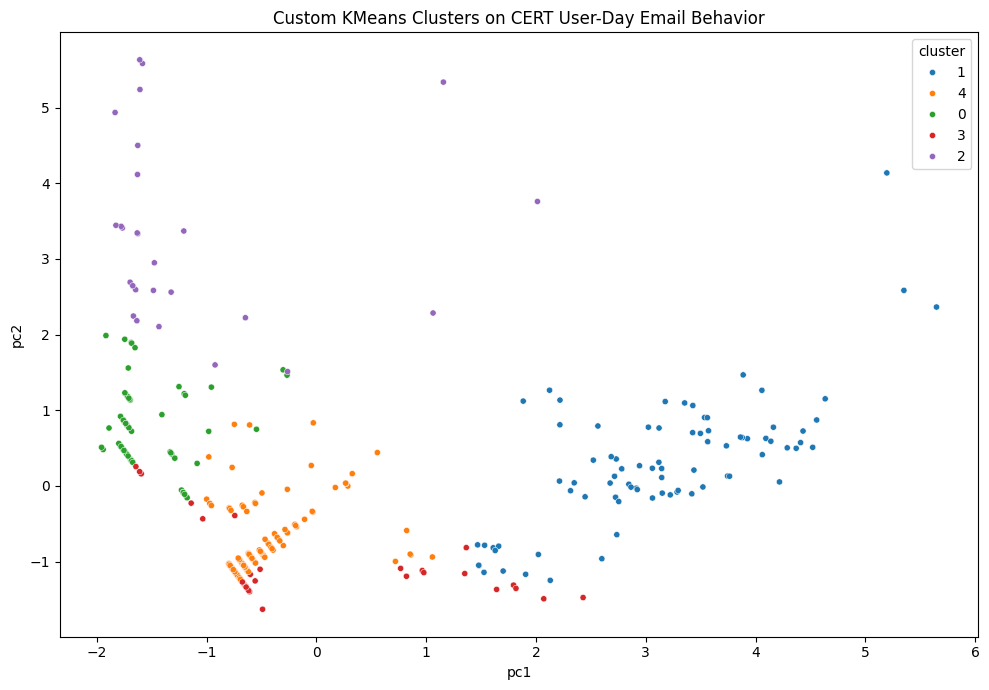

In [31]:
pdf["custom_cluster"] = custom_model.labels_
pdf["anomaly_score"] = custom_model.anomaly_score(X_scaled)

top_anomalies = pdf.sort_values("anomaly_score", ascending=False).head(25)
display(top_anomalies[[
    "user", "day", "anomaly_score", "total_emails",
    "external_ratio", "off_hours_ratio", "weekend_ratio"
]])
top_anomalies.to_csv("top_anomalies.csv", index=False)

pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_scaled)

plot_df = pd.DataFrame({
    "pc1": X_2d[:, 0],
    "pc2": X_2d[:, 1],
    "cluster": pdf["custom_cluster"].astype(str)
})

plt.figure(figsize=(10, 7))
sns.scatterplot(data=plot_df, x="pc1", y="pc2", hue="cluster", palette="tab10", s=20)
plt.title("Custom KMeans Clusters on CERT User-Day Email Behavior")
plt.tight_layout()
plt.show()

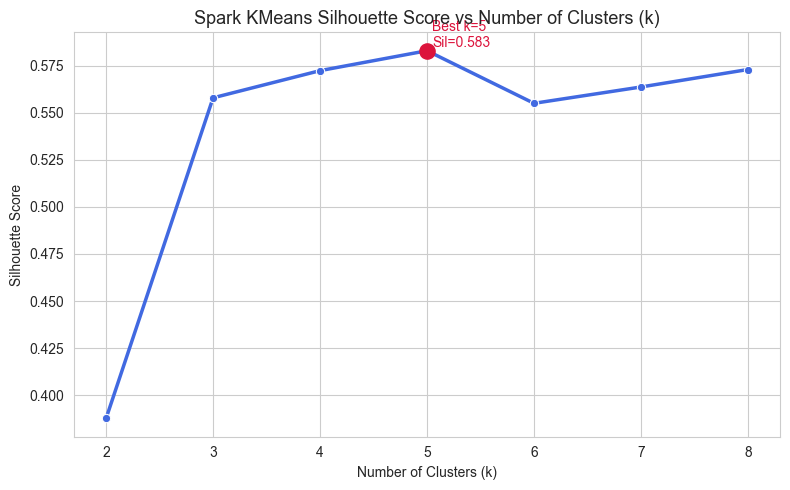

In [41]:
#  Silhouette score vs K
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

plt.figure(figsize=(8, 5))
ax = sns.lineplot(
    data=spark_k_df,
    x="k",
    y="silhouette",
    marker="o",
    linewidth=2.5,
    color="royalblue"
)

best_row = spark_k_df.loc[spark_k_df["silhouette"].idxmax()]
plt.scatter(best_row["k"], best_row["silhouette"], color="crimson", s=120, zorder=5)
plt.text(
    best_row["k"] + 0.05,
    best_row["silhouette"] + 0.002,
    f'Best k={int(best_row["k"])}\nSil={best_row["silhouette"]:.3f}',
    fontsize=10,
    color="crimson"
)

plt.title("Spark KMeans Silhouette Score vs Number of Clusters (k)", fontsize=13)
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.xticks(sorted(spark_k_df["k"].unique()))
plt.tight_layout()
plt.show()

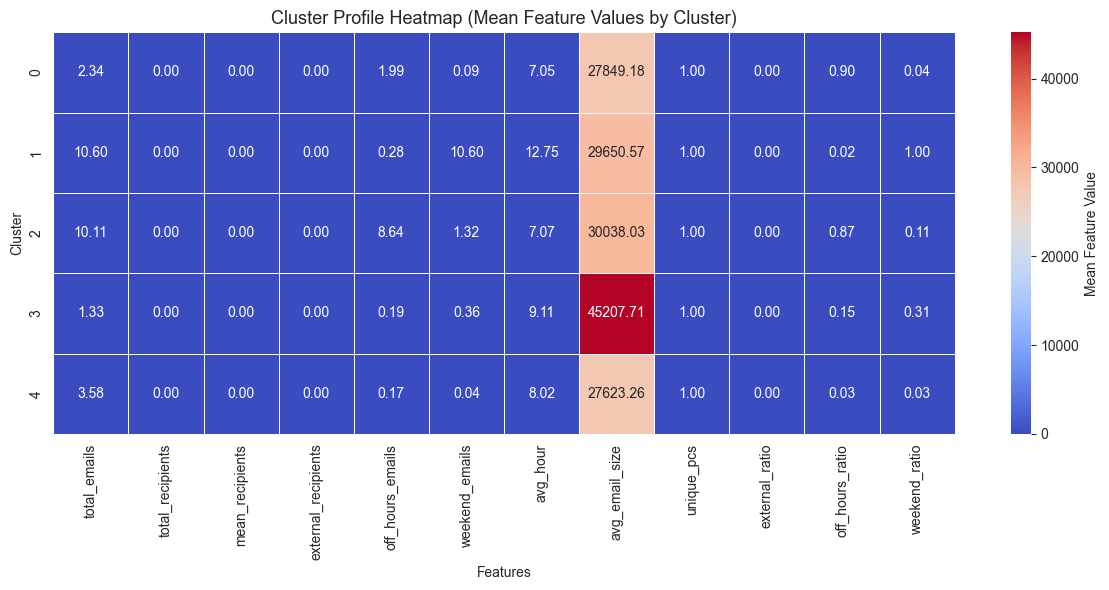

In [45]:
# 2. Cluster centroid heatmap
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Handle either featurecols or feature_cols naming
cols = featurecols if "featurecols" in globals() else feature_cols

cluster_df = pdf[["user", "day"] + cols].copy()
cluster_df["cluster"] = custom_model.labels_

cluster_profile = cluster_df.groupby("cluster")[cols].mean()

plt.figure(figsize=(12, 6))
sns.heatmap(
    cluster_profile,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"label": "Mean Feature Value"}
)

plt.title("Cluster Profile Heatmap (Mean Feature Values by Cluster)", fontsize=13)
plt.xlabel("Features")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()

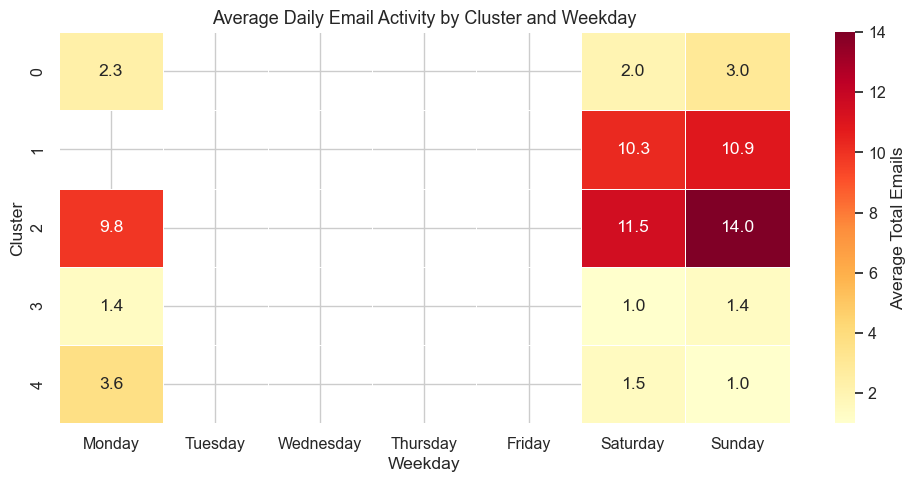

In [67]:
#  Weekday activity heatmap by cluster
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

cols = featurecols if "featurecols" in globals() else feature_cols

cluster_day_df = pdf[["user", "day"] + cols].copy()
cluster_day_df["cluster"] = custom_model.labels_
cluster_day_df["day"] = pd.to_datetime(cluster_day_df["day"])
cluster_day_df["weekday_name"] = cluster_day_df["day"].dt.day_name()

weekday_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

heatmap_df = (
    cluster_day_df.groupby(["cluster", "weekday_name"])["total_emails"]
    .mean()
    .reset_index()
)

pivot_df = heatmap_df.pivot(index="cluster", columns="weekday_name", values="total_emails")
pivot_df = pivot_df.reindex(columns=weekday_order)

plt.figure(figsize=(10, 5))
sns.heatmap(
    pivot_df,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={"label": "Average Total Emails"}
)

plt.title("Average Daily Email Activity by Cluster and Weekday", fontsize=13)
plt.xlabel("Weekday")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()

,model,silhouette
0,SparkKMeans,0.582903
1,CustomKMeans,0.424222
2,DBSCAN,0.406302
3,HDBSCAN,0.534266


Silhouette scores: [{'model': 'SparkKMeans', 'silhouette': 0.5829029586531165}, {'model': 'CustomKMeans', 'silhouette': 0.42422212632266665}, {'model': 'DBSCAN', 'silhouette': 0.4063023781543513}, {'model': 'HDBSCAN', 'silhouette': 0.5342661517347311}]


C:\Users\mamid\AppData\Local\Temp\ipykernel_42400\2169012640.py:83: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=silhouette_compare, x="model", y="silhouette", palette=palette)


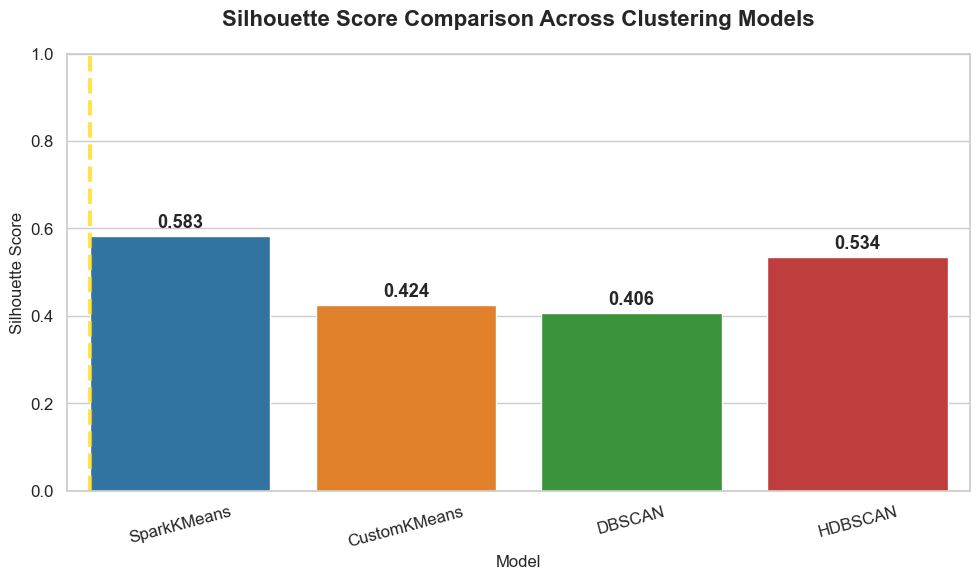


Best model by silhouette score: SparkKMeans (0.583)
Higher is better: >0.5 = strong clusters; >0.7 = excellent separation [web:1][web:2]


In [77]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# -------------------------------------------------------
# 1) Standardize column names from earlier notebook cells
# -------------------------------------------------------

# Spark results dataframe should already exist as sparkkdf
# Python clustering results should already exist as pythonresultsdf

# Make safe copies
spark_compare = spark_k_df.copy()
python_compare = python_results_df.copy()

# Standardize Spark column names to snake_case
spark_compare = spark_compare.rename(columns={
    "trainingcost": "training_cost",
    "iterations": "iterations",
    "clustersizes": "cluster_sizes",
    "runtimesec": "runtime_sec"
})

# Standardize Python results column names to snake_case
python_compare = python_compare.rename(columns={
    "daviesbouldin": "davies_bouldin",
    "calinskiharabasz": "calinski_harabasz",
    "trainingcost": "training_cost",
    "runtimesec": "runtime_sec"
})

# -------------------------------------------------------
# 2) Keep best Spark row and align schemas (silhouette-focused)
# -------------------------------------------------------

best_spark_row = spark_compare.sort_values("silhouette", ascending=False).iloc[0].copy()

# Ensure silhouette column exists in both
if "silhouette" not in best_spark_row.index:
    best_spark_row["silhouette"] = np.nan

# Keep only silhouette-relevant columns for comparison table
silhouette_compare = pd.DataFrame({
    "model": ["SparkKMeans"],
    "silhouette": [best_spark_row.get("silhouette", np.nan)]
})

# Append Python models' silhouette scores (keep one per model)
python_silhouette = python_compare.groupby("model")["silhouette"].max().reset_index()
silhouette_compare = pd.concat([silhouette_compare, python_silhouette], ignore_index=True)

# Optional: save silhouette-only comparison
silhouette_compare.to_csv("silhouette_comparison_only.csv", index=False)

display(silhouette_compare)

# -------------------------------------------------------
# 3) Silhouette-only plotting dataframe
# -------------------------------------------------------

print("Silhouette scores:", silhouette_compare[["model", "silhouette"]].to_dict('records'))

model_order = ["SparkKMeans", "CustomKMeans", "DBSCAN", "HDBSCAN"]
silhouette_compare["model"] = pd.Categorical(silhouette_compare["model"], 
                                            categories=model_order, ordered=True)
silhouette_compare = silhouette_compare.sort_values("model").dropna(subset=["silhouette"])

# -------------------------------------------------------
# 4) Single bar chart for silhouette scores only
# -------------------------------------------------------

sns.set_theme(style="whitegrid", font_scale=1.1)

palette = {
    "SparkKMeans": "#1f77b4",
    "CustomKMeans": "#ff7f0e", 
    "DBSCAN": "#2ca02c",
    "HDBSCAN": "#d62728"
}

plt.figure(figsize=(10, 6))
sns.barplot(data=silhouette_compare, x="model", y="silhouette", palette=palette)

plt.title("Silhouette Score Comparison Across Clustering Models", fontsize=16, weight="bold", pad=20)
plt.ylabel("Silhouette Score", fontsize=12)
plt.xlabel("Model", fontsize=12)
plt.ylim(0, 1)  # Silhouette range [0,1] for visual consistency
plt.xticks(rotation=15)

# Add value labels on bars
for i, v in enumerate(silhouette_compare["silhouette"]):
    plt.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

# Highlight best model
best_idx = silhouette_compare["silhouette"].idxmax()
plt.axvline(x=best_idx - 0.4, color='gold', linestyle='--', linewidth=3, alpha=0.7)

plt.tight_layout()
plt.show()

# -------------------------------------------------------
# 5) Quick interpretation
# -------------------------------------------------------
best_model = silhouette_compare.loc[silhouette_compare["silhouette"].idxmax(), "model"]
best_score = silhouette_compare["silhouette"].max()
print(f"\nBest model by silhouette score: {best_model} ({best_score:.3f})")
print("Higher is better: >0.5 = strong clusters; >0.7 = excellent separation [web:1][web:2]")

,user,day,anomaly_score,total_emails,external_ratio,off_hours_ratio,weekend_ratio
0,KNM0008,2010-01-03,5.190699,27,0.0,0.185185,1.0
1,ECM0004,2010-01-03,4.944368,27,0.0,0.000000,1.0
2,GBM0007,2010-01-03,4.467695,26,0.0,0.000000,1.0
3,TDS0246,2010-01-04,4.046063,1,0.0,0.000000,0.0
4,RHM0148,2010-01-03,3.668648,14,0.0,0.857143,1.0
5,NCT0845,2010-01-02,3.626025,1,0.0,0.000000,1.0
6,CCM0732,2010-01-02,3.514318,14,0.0,0.571429,1.0
7,KAH0848,2010-01-02,3.258320,1,0.0,0.000000,1.0
8,GCH0567,2010-01-02,3.082657,9,0.0,0.555556,1.0
9,KOL0702,2010-01-02,3.071481,1,0.0,0.000000,1.0


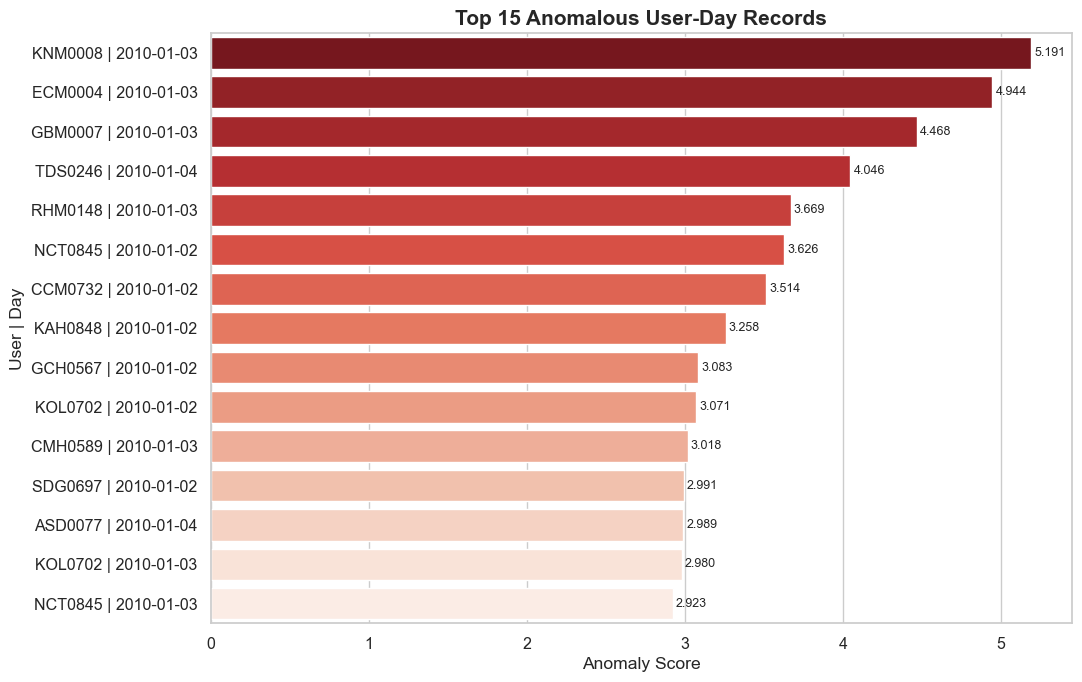

In [79]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.05)

anomaly_df = pdf.copy().rename(columns={
    "totalemails": "total_emails",
    "externalratio": "external_ratio",
    "offhoursratio": "off_hours_ratio",
    "weekendratio": "weekend_ratio"
})

anomaly_df["anomaly_score"] = custom_model.anomaly_score(Xscaled)

anomaly_df = anomaly_df[
    ["user", "day", "anomaly_score", "total_emails", "external_ratio", "off_hours_ratio", "weekend_ratio"]
].sort_values("anomaly_score", ascending=False).reset_index(drop=True)

display(anomaly_df.head(20))

top_n = 15
top_anoms = anomaly_df.head(top_n).copy()
top_anoms["label"] = top_anoms["user"].astype(str) + " | " + top_anoms["day"].astype(str)

plt.figure(figsize=(11, 7))
ax = sns.barplot(
    data=top_anoms,
    y="label",
    x="anomaly_score",
    hue="label",
    dodge=False,
    palette="Reds_r",
    legend=False
)

for i, v in enumerate(top_anoms["anomaly_score"]):
    ax.text(v + 0.02, i, f"{v:.3f}", va="center", fontsize=9)

plt.title("Top 15 Anomalous User-Day Records", fontsize=15, weight="bold")
plt.xlabel("Anomaly Score")
plt.ylabel("User | Day")
plt.tight_layout()
plt.show()